# Output BAB 4.7 - Pembahasan Efektivitas U-Net vs ProCANet

Notebook ini menghasilkan artefak sintesis untuk subbab 4.7: tabel ringkasan efektivitas, grafik trade-off FP/FN, tabel komparasi literatur, narasi pembahasan, dan checklist coverage.

## 0. Setup

Konfigurasi path, folder output, plotting style, dan helper toleran. Jika artefak belum tersedia, notebook membuat tabel status/warning dan tetap lanjut.


In [1]:
from __future__ import annotations

import json
import math
import re
from collections import Counter, defaultdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import rasterio
except Exception as exc:
    rasterio = None
    RASTERIO_IMPORT_ERROR = f"{type(exc).__name__}: {exc}"
else:
    RASTERIO_IMPORT_ERROR = ""

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "font.size": 10,
})

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATASET = ROOT / "dataset"
RUNS = ROOT / "runs"
OUT = ROOT / "outputs" / "bab4"
TABLE_DIR = OUT / "tables"
FIG_DIR = OUT / "figures"
NARRATIVE_DIR = OUT / "narratives"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
NARRATIVE_DIR.mkdir(parents=True, exist_ok=True)

REGIONS = [
    "Aceh_Besar", "Aceh_Tamiang", "Aceh_Timur", "Aceh_Utara", "Agam",
    "Banda_Aceh", "Bireuen", "Langsa", "Pasaman_Barat", "Pidie", "Pidie_Jaya",
]
TEST_REGION = "Aceh_Utara"
CHANNEL_NAMES = ["vv_norm", "vh_norm", "hue", "saturation", "value", "slope_norm", "hand_norm"]

print(f"ROOT: {ROOT}")
print(f"Tables: {TABLE_DIR}")
print(f"Figures: {FIG_DIR}")
print("rasterio:", "available" if rasterio else f"missing ({RASTERIO_IMPORT_ERROR})")


ROOT: /home/nozomi/Productive/skripsi
Tables: /home/nozomi/Productive/skripsi/outputs/bab4/tables
Figures: /home/nozomi/Productive/skripsi/outputs/bab4/figures
rasterio: available


In [2]:
def display_df(df: pd.DataFrame, max_rows: int = 20):
    if df.empty:
        display(df)
    else:
        display(df.head(max_rows))


def save_table(df: pd.DataFrame, name: str) -> Path:
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    print(f"saved table: {path.relative_to(ROOT)} ({len(df)} rows)")
    display_df(df)
    return path


def save_fig(fig, name: str) -> Path:
    path = FIG_DIR / name
    try:
        fig.tight_layout(rect=[0, 0, 1, 0.96])
    except Exception:
        fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    print(f"saved figure: {path.relative_to(ROOT)}")
    plt.show()
    return path


def read_csv_or_status(path: Path, label: str) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame([{"source": str(path.relative_to(ROOT)), "status": "missing", "note": label}])
    try:
        return pd.read_csv(path)
    except Exception as exc:
        return pd.DataFrame([{"source": str(path.relative_to(ROOT)), "status": "read_error", "note": f"{type(exc).__name__}: {exc}"}])


def safe_div(num: float, den: float) -> float:
    return float(num / den) if den else 0.0


def pct(num: float, den: float) -> float:
    return round(100.0 * safe_div(num, den), 4)


def finite_stats(arr: np.ndarray, sample_step: int = 1) -> dict:
    a = np.asarray(arr)
    if sample_step > 1 and a.ndim >= 2:
        a = a[..., ::sample_step, ::sample_step]
    a = a.astype("float64", copy=False)
    finite = np.isfinite(a)
    vals = a[finite]
    if vals.size == 0:
        return {"count": 0, "valid_pct": 0.0, "min": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan, "p2": np.nan, "p98": np.nan}
    return {
        "count": int(vals.size),
        "valid_pct": round(100.0 * vals.size / a.size, 4),
        "min": float(np.min(vals)),
        "max": float(np.max(vals)),
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "p2": float(np.percentile(vals, 2)),
        "p98": float(np.percentile(vals, 98)),
    }


def normalize_image(arr: np.ndarray, p_low: float = 2, p_high: float = 98) -> np.ndarray:
    a = np.asarray(arr, dtype="float32")
    finite = np.isfinite(a)
    if not finite.any():
        return np.zeros_like(a, dtype="float32")
    lo, hi = np.percentile(a[finite], [p_low, p_high])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(np.nanmin(a[finite])), float(np.nanmax(a[finite]))
    if hi <= lo:
        return np.zeros_like(a, dtype="float32")
    return np.clip((a - lo) / (hi - lo), 0, 1)


def raster_stats(path: Path, band: int = 1, sample_step: int = 10) -> dict:
    if rasterio is None:
        return {"status": "skipped", "note": f"rasterio unavailable: {RASTERIO_IMPORT_ERROR}"}
    if not path.exists():
        return {"status": "missing", "note": str(path.relative_to(ROOT))}
    try:
        with rasterio.open(path) as src:
            arr = src.read(band, masked=True)
            vals = arr.compressed() if np.ma.isMaskedArray(arr) else np.asarray(arr).ravel()
            if sample_step > 1:
                arr2 = np.asarray(arr.filled(np.nan) if np.ma.isMaskedArray(arr) else arr)
                vals = arr2[::sample_step, ::sample_step].ravel()
            stats = finite_stats(vals)
            stats.update({
                "status": "ok",
                "height": src.height,
                "width": src.width,
                "crs": str(src.crs),
                "transform": str(src.transform),
            })
            return stats
    except Exception as exc:
        return {"status": "read_error", "note": f"{type(exc).__name__}: {exc}"}


def load_npz(path: Path):
    return np.load(path, allow_pickle=False)


def first_npz(path: Path) -> Path | None:
    files = sorted(path.glob("*.npz"))
    return files[0] if files else None


def parse_tile_rc(path: Path) -> tuple[int | None, int | None]:
    m = re.search(r"_r(\d+)_c(\d+)", path.stem)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))


def choose_tile(region: str = TEST_REGION) -> Path | None:
    tile_dir = DATASET / "tiles" / "7ch" / "by_region" / region
    candidates = []
    for path in sorted(tile_dir.glob("*.npz")):
        try:
            z = load_npz(path)
            y = np.asarray(z["y"])[0]
            valid = np.asarray(z.get("valid_mask", np.ones_like(y)))[0]
            positives = int(((y > 0) & (valid > 0)).sum())
            valid_count = int((valid > 0).sum())
            candidates.append((positives, valid_count, path))
        except Exception:
            continue
    if not candidates:
        return None
    positives = [c for c in candidates if c[0] > 0]
    if positives:
        return sorted(positives, key=lambda x: x[0], reverse=True)[0][2]
    return sorted(candidates, key=lambda x: x[1], reverse=True)[0][2]


def find_matching_prediction(model: str, tile_path: Path) -> Path | None:
    pred_dir = RUNS / "final" / model / "eval_test" / "predictions" / TEST_REGION
    candidate = pred_dir / tile_path.name
    if candidate.exists():
        return candidate
    r, c = parse_tile_rc(tile_path)
    if r is None:
        return first_npz(pred_dir)
    matches = sorted(pred_dir.glob(f"*r{r:06d}_c{c:06d}.npz"))
    return matches[0] if matches else first_npz(pred_dir)


## 4.7 Pembahasan Efektivitas U-Net vs ProCANet

Data dibaca dari artefak 4.4.1, 4.5, dan 4.6 agar pembahasan 4.7 menjadi sintesis, bukan perhitungan ulang tersembunyi.

In [3]:
metrics = pd.read_csv(TABLE_DIR / '4_5_final_metrics.csv')
confusion = pd.read_csv(TABLE_DIR / '4_5_confusion_matrix_pixels.csv')
architecture = pd.read_csv(TABLE_DIR / '4_4_1_model_architecture_specs.csv')
visual_aspects_path = TABLE_DIR / '4_6_visual_model_aspects.csv'
visual_aspects = pd.read_csv(visual_aspects_path) if visual_aspects_path.exists() else pd.DataFrame()

metrics_idx = metrics.set_index('model')
conf_idx = confusion.set_index('model')

def fmt_float(value: float, digits: int = 4) -> str:
    return f'{float(value):.{digits}f}' if pd.notna(value) else '-'

u = metrics_idx.loc['U-Net']
p = metrics_idx.loc['ProCANet']
uc = conf_idx.loc['U-Net']
pc = conf_idx.loc['ProCANet']

def get_arch(component: str, model: str) -> str:
    row = architecture[architecture['komponen'] == component]
    if row.empty:
        return '-'
    return str(row.iloc[0][model])

summary_rows = [
    {
        'aspek': 'Strategi fusi',
        'U-Net': get_arch('Mekanisme fusi', 'U-Net'),
        'ProCANet': get_arch('Mekanisme fusi', 'ProCANet'),
        'interpretasi': 'U-Net menjadi baseline fusi langsung; ProCANet menambah seleksi fitur melalui cross-attention.',
    },
    {
        'aspek': 'Input arsitektur',
        'U-Net': get_arch('Input utama', 'U-Net'),
        'ProCANet': get_arch('Input utama', 'ProCANet'),
        'interpretasi': 'Encoder kedua ProCANet mengulang VV/VH karena SAR stabil pada kondisi awan dan hujan.',
    },
    {
        'aspek': 'IoU final Aceh_Utara',
        'U-Net': fmt_float(u['iou']),
        'ProCANet': fmt_float(p['iou']),
        'interpretasi': 'U-Net memberi overlap spasial final lebih tinggi terhadap label UNOSAT.',
    },
    {
        'aspek': 'Dice/F1 final Aceh_Utara',
        'U-Net': fmt_float(u['dice_f1']),
        'ProCANet': fmt_float(p['dice_f1']),
        'interpretasi': 'Dice/F1 U-Net sedikit lebih tinggi sehingga cakupan label banjir lebih lengkap.',
    },
    {
        'aspek': 'Accuracy final',
        'U-Net': fmt_float(u['accuracy']),
        'ProCANet': fmt_float(p['accuracy']),
        'interpretasi': 'Akurasi tinggi pada kedua model, tetapi tetap pelengkap karena kelas non-banjir dominan.',
    },
    {
        'aspek': 'Precision dan FP',
        'U-Net': f"precision {fmt_float(u['precision'])}; FP {int(uc['fp']):,}",
        'ProCANet': f"precision {fmt_float(p['precision'])}; FP {int(pc['fp']):,}",
        'interpretasi': 'ProCANet lebih presisi dan menekan false positive.',
    },
    {
        'aspek': 'Recall dan FN',
        'U-Net': f"recall {fmt_float(u['recall'])}; FN {int(uc['fn']):,}",
        'ProCANet': f"recall {fmt_float(p['recall'])}; FN {int(pc['fn']):,}",
        'interpretasi': 'U-Net lebih sensitif; ProCANet lebih berisiko melewatkan banjir tipis atau samar.',
    },
    {
        'aspek': 'Kelebihan utama',
        'U-Net': 'Sederhana, stabil, dan memanfaatkan stack 7-channel secara langsung.',
        'ProCANet': 'Lebih selektif melalui dual encoder dan Progressive Cross-Attention.',
        'interpretasi': 'Keduanya efektif, tetapi menonjol pada risiko operasional yang berbeda.',
    },
    {
        'aspek': 'Keterbatasan utama',
        'U-Net': 'FP lebih tinggi sehingga potensi overprediction lebih besar.',
        'ProCANet': 'FN lebih tinggi sehingga sensitivitas terhadap banjir tipis lebih rendah.',
        'interpretasi': 'Tidak ada model yang unggul mutlak pada semua kriteria.',
    },
]
comparison = pd.DataFrame(summary_rows)
save_table(comparison, '4_7_unet_vs_procanet_effectiveness_summary.csv')


saved table: outputs/bab4/tables/4_7_unet_vs_procanet_effectiveness_summary.csv (9 rows)


,aspek,U-Net,ProCANet,interpretasi
0,Strategi fusi,Fusi langsung 7-channel sejak input dan skip c...,ProgressiveCrossAttentionBlock pada skip featu...,U-Net menjadi baseline fusi langsung; ProCANet...
1,Input arsitektur,"7 channel: VV, VH, Hue, Saturation, Value, Slo...","Encoder 1: 7 channel penuh; Encoder 2: VV, VH",Encoder kedua ProCANet mengulang VV/VH karena ...
2,IoU final Aceh_Utara,0.8510,0.8383,U-Net memberi overlap spasial final lebih ting...
3,Dice/F1 final Aceh_Utara,0.9195,0.9120,Dice/F1 U-Net sedikit lebih tinggi sehingga ca...
4,Accuracy final,0.9707,0.9688,"Akurasi tinggi pada kedua model, tetapi tetap ..."
5,Precision dan FP,"precision 0.9322; FP 1,227,212","precision 0.9473; FP 908,418",ProCANet lebih presisi dan menekan false posit...
6,Recall dan FN,"recall 0.9072; FN 1,725,554","recall 0.8793; FN 2,244,344",U-Net lebih sensitif; ProCANet lebih berisiko ...
7,Kelebihan utama,"Sederhana, stabil, dan memanfaatkan stack 7-ch...",Lebih selektif melalui dual encoder dan Progre...,"Keduanya efektif, tetapi menonjol pada risiko ..."
8,Keterbatasan utama,FP lebih tinggi sehingga potensi overpredictio...,FN lebih tinggi sehingga sensitivitas terhadap...,Tidak ada model yang unggul mutlak pada semua ...


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_7_unet_vs_procanet_effectiveness_summary.csv')

saved table: outputs/bab4/tables/4_7_fp_fn_tradeoff_summary.csv (2 rows)


,model,FP,FN,precision,recall
0,U-Net,1227212,1725554,0.932163,0.907173
1,ProCANet,908418,2244344,0.947347,0.879264


saved figure: outputs/bab4/figures/4_7_fp_fn_tradeoff_bar_chart.png


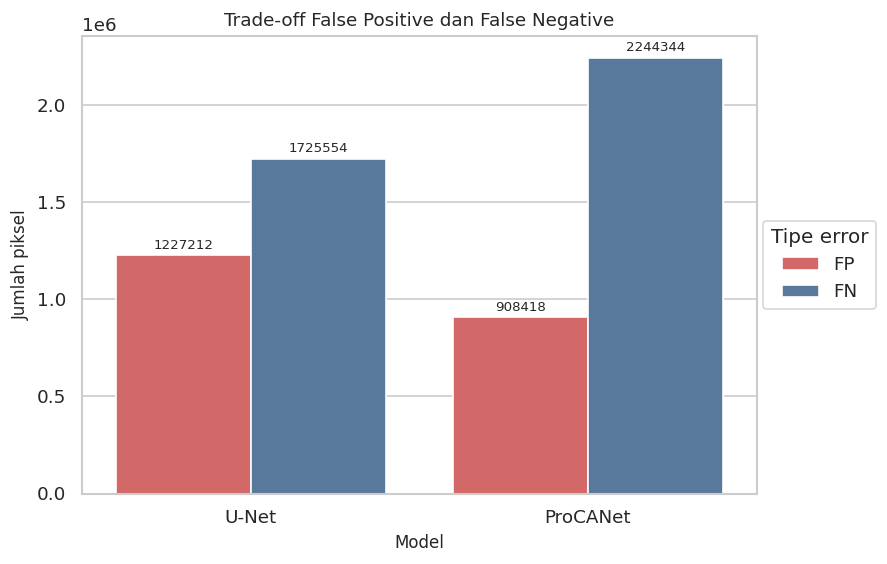

In [4]:
tradeoff = pd.DataFrame([
    {'model': 'U-Net', 'FP': int(uc['fp']), 'FN': int(uc['fn']), 'precision': float(u['precision']), 'recall': float(u['recall'])},
    {'model': 'ProCANet', 'FP': int(pc['fp']), 'FN': int(pc['fn']), 'precision': float(p['precision']), 'recall': float(p['recall'])},
])
save_table(tradeoff, '4_7_fp_fn_tradeoff_summary.csv')

fig, ax = plt.subplots(figsize=(7.5, 4.8))
plot_df = tradeoff.melt(id_vars=['model'], value_vars=['FP', 'FN'], var_name='error_type', value_name='pixel_count')
sns.barplot(data=plot_df, x='model', y='pixel_count', hue='error_type', ax=ax, palette=['#E45756', '#4C78A8'])
ax.set_title('Trade-off False Positive dan False Negative')
ax.set_xlabel('Model')
ax.set_ylabel('Jumlah piksel')
ax.legend(title='Tipe error', loc='center left', bbox_to_anchor=(1.01, 0.5), borderaxespad=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=2, fontsize=8)
fig.tight_layout()
path = FIG_DIR / '4_7_fp_fn_tradeoff_bar_chart.png'
fig.savefig(path, bbox_inches='tight', dpi=300)
print(f'saved figure: {path.relative_to(ROOT)}')
plt.show()


In [5]:
literature_rows = [
    {
        'penelitian': 'ProCANet asli / Feliren et al.',
        'model': 'Progressive Cross-Attention Network',
        'data_modalitas': 'Fusi multimodal; encoder kedua mengulang modalitas air paling informatif seperti NIR',
        'fokus_perbandingan': 'Menunjukkan manfaat attention untuk seleksi fitur lintas modalitas',
        'konteks_dengan_penelitian_ini': 'Tidak dibandingkan langsung karena dataset, wilayah, label, dan komposisi channel berbeda.',
    },
    {
        'penelitian': 'Penelitian ini',
        'model': 'U-Net baseline 7-channel vs ProCANet dua encoder',
        'data_modalitas': 'Sentinel-1 VV/VH, Sentinel-2 HSV, Slope, HAND; encoder kedua ProCANet memakai VV/VH',
        'fokus_perbandingan': 'Evaluasi final Aceh_Utara menunjukkan U-Net unggul IoU/Dice/recall, ProCANet unggul precision dan FP lebih rendah',
        'konteks_dengan_penelitian_ini': 'Hasil memperluas ide ProCANet ke konfigurasi SAR-optis-topografi, tetapi tidak membuktikan dominasi ProCANet mutlak.',
    },
]
literature = pd.DataFrame(literature_rows)
save_table(literature, '4_7_literature_context_comparison.csv')


saved table: outputs/bab4/tables/4_7_literature_context_comparison.csv (2 rows)


,penelitian,model,data_modalitas,fokus_perbandingan,konteks_dengan_penelitian_ini
0,ProCANet asli / Feliren et al.,Progressive Cross-Attention Network,Fusi multimodal; encoder kedua mengulang modal...,Menunjukkan manfaat attention untuk seleksi fi...,"Tidak dibandingkan langsung karena dataset, wi..."
1,Penelitian ini,U-Net baseline 7-channel vs ProCANet dua encoder,"Sentinel-1 VV/VH, Sentinel-2 HSV, Slope, HAND;...",Evaluasi final Aceh_Utara menunjukkan U-Net un...,Hasil memperluas ide ProCANet ke konfigurasi S...


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_7_literature_context_comparison.csv')

In [6]:
lines = [
    '# Pembahasan Efektivitas U-Net vs ProCANet 4.7',
    '',
    f"U-Net berperan sebagai baseline fusi langsung karena seluruh channel VV, VH, HSV, Slope, dan HAND digabung sejak input. Pada evaluasi final Aceh_Utara, baseline ini tetap kompetitif dan bahkan memperoleh IoU {u['iou']:.4f}, Dice/F1 {u['dice_f1']:.4f}, dan recall {u['recall']:.4f}, lebih tinggi daripada ProCANet pada tiga metrik tersebut. Hasil ini menunjukkan bahwa stack 7-channel langsung sudah cukup kuat untuk menangkap pola spasial banjir pada wilayah uji.",
    '',
    f"ProCANet memakai dua encoder dan Progressive Cross-Attention untuk menyeleksi fitur lintas sensor. Pada implementasi ini, encoder pertama menerima 7 channel penuh, sedangkan encoder kedua menerima VV/VH karena SAR lebih stabil pada kondisi awan dan hujan. Walaupun IoU dan Dice/F1 final ProCANet lebih rendah, ProCANet mencapai precision {p['precision']:.4f} dan FP {int(pc['fp']):,}, lebih baik daripada U-Net yang memiliki precision {u['precision']:.4f} dan FP {int(uc['fp']):,}. Ini menunjukkan karakter ProCANet yang lebih selektif terhadap prediksi banjir.",
    '',
    f"Trade-off utama muncul pada FN. U-Net memiliki FN {int(uc['fn']):,}, sedangkan ProCANet memiliki FN {int(pc['fn']):,}. Dengan kata lain, penurunan FP pada ProCANet dibayar oleh peningkatan banjir yang terlewat. Untuk aplikasi yang memprioritaskan cakupan banjir dan mitigasi risiko terlewat, U-Net lebih menguntungkan. Untuk aplikasi yang lebih sensitif terhadap alarm palsu atau area non-banjir yang salah ditandai, ProCANet tetap memiliki nilai praktis.",
    '',
    'Dibandingkan literatur ProCANet/Feliren et al., hasil ini sebaiknya dibaca sebagai perluasan konteks, bukan pembandingan langsung. Paper ProCANet asli dan penelitian ini berbeda pada dataset, wilayah, label, serta komposisi modalitas. Penelitian ini mengadaptasi gagasan attention dengan mengulang kanal SAR VV/VH pada encoder kedua, bukan modalitas NIR sebagaimana insight awal ProCANet. Karena itu, hasil yang lebih kuat pada U-Net tidak berarti mekanisme attention gagal, tetapi menunjukkan bahwa manfaat attention sangat bergantung pada kualitas data, noise label, jumlah sampel, dan pilihan modalitas.',
    '',
    'Kesimpulan yang paling defensibel adalah bahwa ProCANet tidak unggul mutlak pada eksperimen ini. U-Net lebih kuat pada overlap dan recall, sedangkan ProCANet lebih kuat pada precision dan pengurangan FP. Pembahasan 4.7 perlu menekankan karakter trade-off ini agar kontribusi penelitian tetap jujur dan operasional.',
]
path = NARRATIVE_DIR / '4_7_unet_procanet_effectiveness_discussion.md'
path.write_text('\n'.join(lines) + '\n')
print(f'saved narrative: {path.relative_to(ROOT)}')
print('\n'.join(lines))


saved narrative: outputs/bab4/narratives/4_7_unet_procanet_effectiveness_discussion.md
# Pembahasan Efektivitas U-Net vs ProCANet 4.7

U-Net berperan sebagai baseline fusi langsung karena seluruh channel VV, VH, HSV, Slope, dan HAND digabung sejak input. Pada evaluasi final Aceh_Utara, baseline ini tetap kompetitif dan bahkan memperoleh IoU 0.8510, Dice/F1 0.9195, dan recall 0.9072, lebih tinggi daripada ProCANet pada tiga metrik tersebut. Hasil ini menunjukkan bahwa stack 7-channel langsung sudah cukup kuat untuk menangkap pola spasial banjir pada wilayah uji.

ProCANet memakai dua encoder dan Progressive Cross-Attention untuk menyeleksi fitur lintas sensor. Pada implementasi ini, encoder pertama menerima 7 channel penuh, sedangkan encoder kedua menerima VV/VH karena SAR lebih stabil pada kondisi awan dan hujan. Walaupun IoU dan Dice/F1 final ProCANet lebih rendah, ProCANet mencapai precision 0.9473 dan FP 908,418, lebih baik daripada U-Net yang memiliki precision 0.9322 dan FP 1,227,

In [7]:
expected = [
    ('sangat_disarankan', 'Ringkasan perbandingan U-Net vs ProCANet', TABLE_DIR / '4_7_unet_vs_procanet_effectiveness_summary.csv'),
    ('opsional', 'Bar chart trade-off FP/FN', FIG_DIR / '4_7_fp_fn_tradeoff_bar_chart.png'),
    ('opsional_terpenuhi_4_4_1', 'Diagram arsitektur tambahan tidak dibuat ulang karena sudah tersedia di 4.4.1', FIG_DIR / '4_4_1_procanet_architecture_diagram.png'),
    ('opsional', 'Tabel trade-off FP/FN', TABLE_DIR / '4_7_fp_fn_tradeoff_summary.csv'),
    ('opsional', 'Tabel komparasi literatur', TABLE_DIR / '4_7_literature_context_comparison.csv'),
    ('narasi_wajib', 'Pembahasan U-Net sebagai baseline fusi langsung', NARRATIVE_DIR / '4_7_unet_procanet_effectiveness_discussion.md'),
    ('narasi_wajib', 'Pembahasan ProCANet sebagai dual encoder attention', NARRATIVE_DIR / '4_7_unet_procanet_effectiveness_discussion.md'),
    ('narasi_wajib', 'Pembahasan trade-off dan klaim jujur', NARRATIVE_DIR / '4_7_unet_procanet_effectiveness_discussion.md'),
    ('narasi_wajib', 'Komparasi dengan literatur ProCANet/Feliren', NARRATIVE_DIR / '4_7_unet_procanet_effectiveness_discussion.md'),
]
coverage = pd.DataFrame([
    {
        'priority': priority,
        'todo_item': item,
        'artifact': str(path.relative_to(ROOT)),
        'exists': path.exists(),
        'size_bytes': path.stat().st_size if path.exists() else 0,
    }
    for priority, item, path in expected
])
save_table(coverage, '4_7_todo_coverage_checklist.csv')
missing = coverage[~coverage['exists']]
if missing.empty:
    print('All 4.7 checklist artifacts are available.')
else:
    display(missing)


saved table: outputs/bab4/tables/4_7_todo_coverage_checklist.csv (9 rows)


,priority,todo_item,artifact,exists,size_bytes
0,sangat_disarankan,Ringkasan perbandingan U-Net vs ProCANet,outputs/bab4/tables/4_7_unet_vs_procanet_effec...,True,1562
1,opsional,Bar chart trade-off FP/FN,outputs/bab4/figures/4_7_fp_fn_tradeoff_bar_ch...,True,74082
2,opsional_terpenuhi_4_4_1,Diagram arsitektur tambahan tidak dibuat ulang...,outputs/bab4/figures/4_4_1_procanet_architectu...,True,244853
3,opsional,Tabel trade-off FP/FN,outputs/bab4/tables/4_7_fp_fn_tradeoff_summary...,True,151
4,opsional,Tabel komparasi literatur,outputs/bab4/tables/4_7_literature_context_com...,True,778
5,narasi_wajib,Pembahasan U-Net sebagai baseline fusi langsung,outputs/bab4/narratives/4_7_unet_procanet_effe...,True,2363
6,narasi_wajib,Pembahasan ProCANet sebagai dual encoder atten...,outputs/bab4/narratives/4_7_unet_procanet_effe...,True,2363
7,narasi_wajib,Pembahasan trade-off dan klaim jujur,outputs/bab4/narratives/4_7_unet_procanet_effe...,True,2363
8,narasi_wajib,Komparasi dengan literatur ProCANet/Feliren,outputs/bab4/narratives/4_7_unet_procanet_effe...,True,2363


All 4.7 checklist artifacts are available.
